# 0825_kimjaehak_010_type_probability_calibration

`kimjaehak_006`의 고정된 검사유형별 XGBoost score를 직전 시간 구간에서 확률로 보정하고, 비용비율에서 미리 정한 하나의 확률 threshold를 다음 구간에 적용합니다.

`kimjaehak_008`처럼 type·구간별 raw threshold를 직접 최적화하지 않고, **확률의 의미를 보정한 뒤 고정된 의사결정 기준을 쓸 수 있는가**를 검증합니다.

## 1. 설정과 라이브러리

False positive 비용을 1, false negative 비용을 100으로 두면, 보정된 불량 확률 `p`에 대해 재검사를 선택하는 손익분기 threshold는 `1 / (1 + 100)`입니다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_010_type_probability_calibration"
RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
N_WINDOWS = 10
TRAIN_WINDOWS = [f"W{number:02d}" for number in range(1, 7)]
WALK_FORWARD_PAIRS = [("W07", "W08"), ("W08", "W09"), ("W09", "W10")]
RAW_BASELINE_THRESHOLD = 0.5
COST_FP = 1
COST_FN = 100
COST_PROBABILITY_THRESHOLD = COST_FP / (COST_FP + COST_FN)
MIN_POSITIVES_FOR_TYPE_CALIBRATION = 20
MIN_NEGATIVES_FOR_TYPE_CALIBRATION = 100
PROBABILITY_EPSILON = 1e-6

assert DATA_PATH.exists(), f"파일을 찾을 수 없습니다: {DATA_PATH.resolve()}"
assert MAPPING_PATH.exists(), f"파일을 찾을 수 없습니다: {MAPPING_PATH.resolve()}"
print("experiment:", EXPERIMENT_ID)
print("cost threshold:", COST_PROBABILITY_THRESHOLD)

experiment: 0825_kimjaehak_010_type_probability_calibration
cost threshold: 0.009900990099009901


## 2. 데이터 준비와 10개 시간 구간

중복 제거와 timestamp-group 기준 구간 생성은 `kimjaehak_007/008`과 동일합니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

dedup_columns = [
    column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors="raise", utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side="left"))
    return timestamp_group_sizes.index[position]

window_end_times = pd.DatetimeIndex(
    [boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)]
)
window_number = np.searchsorted(
    window_end_times.astype("int64").to_numpy(),
    clean_df[TIME_COLUMN].astype("int64").to_numpy(),
    side="left",
)
clean_df["window"] = pd.Categorical(
    [f"W{number + 1:02d}" for number in window_number],
    categories=[f"W{number:02d}" for number in range(1, N_WINDOWS + 1)],
    ordered=True,
)

window_summary = clean_df.groupby("window", observed=False).agg(
    rows=(TARGET, "size"), positives=(TARGET, "sum"), positive_rate=(TARGET, "mean")
)
window_summary["positive_rate_pct"] = window_summary["positive_rate"] * 100
assert len(clean_df) == 391_992
assert clean_df.groupby(TIME_COLUMN)["window"].nunique().max() == 1
display(window_summary)

,rows,positives,positive_rate,positive_rate_pct
window,,,,
W01,39210,73,0.001862,0.186177
W02,39196,712,0.018165,1.816512
W03,39202,414,0.010561,1.056069
W04,39192,201,0.005129,0.512860
W05,39202,277,0.007066,0.706597
W06,39220,147,0.003748,0.374809
W07,39180,36,0.000919,0.091884
W08,39194,327,0.008343,0.834311
W09,39197,941,0.024007,2.400694


## 3. mapping 기반 고정 모델 5개

W01~W06으로만 모델을 학습하고 W07~W10 raw score를 계산합니다. XGBoost 설정은 `kimjaehak_006`과 같습니다.

In [3]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())
with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)
assert set(feature_mapping) == {str(value) for value in inspection_types}

meta_columns = [column for column in clean_df.columns if column.startswith("meta_feat")]
feature_columns_by_type = {}
models_by_type = {}
raw_probability = pd.Series(np.nan, index=clean_df.index, dtype="float64")
train_mask = clean_df["window"].isin(TRAIN_WINDOWS)
validation_mask = clean_df["window"].isin(["W07", "W08"])

for inspection_type in inspection_types:
    mapped_columns = feature_mapping[str(inspection_type)]
    feature_columns = meta_columns + mapped_columns
    feature_columns_by_type[inspection_type] = feature_columns
    type_train = clean_df.loc[train_mask & (clean_df[TYPE_COLUMN] == inspection_type)]
    type_validation = clean_df.loc[
        validation_mask & (clean_df[TYPE_COLUMN] == inspection_type)
    ]
    type_future = clean_df.loc[
        (~train_mask) & (clean_df[TYPE_COLUMN] == inspection_type)
    ]

    model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )
    model.fit(
        type_train[feature_columns],
        type_train[TARGET].astype("int8"),
        eval_set=[(
            type_validation[feature_columns],
            type_validation[TARGET].astype("int8"),
        )],
        verbose=False,
    )
    models_by_type[inspection_type] = model
    raw_probability.loc[type_future.index] = model.predict_proba(
        type_future[feature_columns]
    )[:, 1]

assert raw_probability.loc[~train_mask].notna().all()
print("trained models:", len(models_by_type))

trained models: 5


## 4. Platt calibration과 평가 함수

Platt calibration은 XGBoost 확률의 logit을 입력으로 받는 Logistic Regression입니다. 표본이 충분한 type은 별도로 fit합니다. 희소 type은 해당 직전 구간 전체의 pooled calibrator를 사용하고, 과거에 충분한 표본으로 만든 type calibrator가 있으면 그것을 유지합니다.

In [4]:
def probability_to_logit(probabilities):
    probabilities = np.clip(
        np.asarray(probabilities, dtype="float64"),
        PROBABILITY_EPSILON,
        1 - PROBABILITY_EPSILON,
    )
    return np.log(probabilities / (1 - probabilities)).reshape(-1, 1)

def fit_platt_calibrator(probabilities, y_true):
    y_true = np.asarray(y_true, dtype="int8")
    assert len(np.unique(y_true)) == 2
    calibrator = LogisticRegression(
        random_state=RANDOM_STATE, max_iter=2_000, solver="lbfgs"
    )
    calibrator.fit(probability_to_logit(probabilities), y_true)
    calibrator.original_slope_ = float(calibrator.coef_[0, 0])
    calibrator.monotonic_fallback_ = calibrator.original_slope_ < 0
    if calibrator.monotonic_fallback_:
        prevalence = np.clip(
            y_true.mean(), PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON
        )
        calibrator.coef_[0, 0] = 0.0
        calibrator.intercept_[0] = np.log(prevalence / (1 - prevalence))
    return calibrator

def apply_platt_calibrator(calibrator, probabilities):
    return calibrator.predict_proba(probability_to_logit(probabilities))[:, 1]

def safe_average_precision(y_true, probabilities):
    return (
        average_precision_score(y_true, probabilities)
        if len(np.unique(y_true)) > 1 else np.nan
    )

def safe_roc_auc(y_true, probabilities):
    return (
        roc_auc_score(y_true, probabilities)
        if len(np.unique(y_true)) > 1 else np.nan
    )

def evaluate_policy(y_true, predictions, probabilities):
    y_true = np.asarray(y_true, dtype="int8")
    predictions = np.asarray(predictions, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    clipped_probabilities = np.clip(
        probabilities, PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON
    )
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "slip_rate": fn / (fn + tp) if (fn + tp) else np.nan,
        "volume_reduction": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "pr_auc": safe_average_precision(y_true, probabilities),
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "brier": brier_score_loss(y_true, probabilities),
        "log_loss": log_loss(y_true, clipped_probabilities, labels=[0, 1]),
        "mean_probability": probabilities.mean(),
        "observed_rate": y_true.mean(),
        "total_cost_1_to_100": int(fp * COST_FP + fn * COST_FN),
    }

## 5. 직전 구간 calibration → 다음 구간 적용

각 단계에서 pooled calibrator를 먼저 만들고, 충분한 type만 별도 calibrator로 대체합니다. W09의 type 4처럼 표본이 다시 희소해지면 과거 type calibrator를 유지합니다.

In [5]:
current_type_calibrators = {}
calibrator_rows = []
calibrated_rows = []

for calibration_window, evaluation_window in WALK_FORWARD_PAIRS:
    calibration_df_all = clean_df.loc[clean_df["window"] == calibration_window]
    pooled_calibrator = fit_platt_calibrator(
        raw_probability.loc[calibration_df_all.index],
        calibration_df_all[TARGET],
    )

    for inspection_type in inspection_types:
        calibration_df = calibration_df_all.loc[
            calibration_df_all[TYPE_COLUMN] == inspection_type
        ]
        evaluation_df = clean_df.loc[
            (clean_df["window"] == evaluation_window)
            & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        positives = int(calibration_df[TARGET].sum())
        negatives = len(calibration_df) - positives
        enough_samples = (
            positives >= MIN_POSITIVES_FOR_TYPE_CALIBRATION
            and negatives >= MIN_NEGATIVES_FOR_TYPE_CALIBRATION
        )

        if enough_samples:
            calibrator = fit_platt_calibrator(
                raw_probability.loc[calibration_df.index],
                calibration_df[TARGET],
            )
            current_type_calibrators[inspection_type] = calibrator
            source = "type_updated"
        elif inspection_type in current_type_calibrators:
            calibrator = current_type_calibrators[inspection_type]
            source = "type_retained"
        else:
            calibrator = pooled_calibrator
            source = "pooled_fallback"

        evaluation_raw_probability = raw_probability.loc[evaluation_df.index]
        evaluation_calibrated_probability = apply_platt_calibrator(
            calibrator, evaluation_raw_probability
        )
        calibrated_rows.append(pd.DataFrame({
            "index": evaluation_df.index,
            "evaluation_window": evaluation_window,
            "inspection_type": inspection_type,
            "y_true": evaluation_df[TARGET].astype("int8").to_numpy(),
            "raw_probability": evaluation_raw_probability.to_numpy(),
            "calibrated_probability": evaluation_calibrated_probability,
            "calibrator_source": source,
        }))
        calibrator_rows.append({
            "calibration_window": calibration_window,
            "evaluation_window": evaluation_window,
            "inspection_type": inspection_type,
            "calibration_rows": len(calibration_df),
            "calibration_positives": positives,
            "calibration_negatives": negatives,
            "source": source,
            "platt_intercept": float(calibrator.intercept_[0]),
            "platt_raw_slope": calibrator.original_slope_,
            "platt_slope": float(calibrator.coef_[0, 0]),
            "monotonic_fallback": calibrator.monotonic_fallback_,
        })

calibrator_history = pd.DataFrame(calibrator_rows)
calibrated_predictions = pd.concat(calibrated_rows, ignore_index=True)
display(calibrator_history)
display(calibrator_history.groupby(["evaluation_window", "source"]).size().unstack(fill_value=0))

,calibration_window,evaluation_window,inspection_type,calibration_rows,calibration_positives,calibration_negatives,source,platt_intercept,platt_raw_slope,platt_slope,monotonic_fallback
0,W07,W08,0,11337,1,11336,pooled_fallback,-2.714012,0.534807,0.534807,False
1,W07,W08,1,4480,25,4455,type_updated,-2.856215,0.409614,0.409614,False
2,W07,W08,2,11359,7,11352,pooled_fallback,-2.714012,0.534807,0.534807,False
3,W07,W08,3,11703,3,11700,pooled_fallback,-2.714012,0.534807,0.534807,False
4,W07,W08,4,301,0,301,pooled_fallback,-2.714012,0.534807,0.534807,False
5,W08,W09,0,12155,7,12148,pooled_fallback,-1.850175,0.421320,0.421320,False
6,W08,W09,1,6014,214,5800,type_updated,-1.187352,0.712896,0.712896,False
7,W08,W09,2,4538,25,4513,type_updated,-2.910451,0.336464,0.336464,False
8,W08,W09,3,15625,21,15604,type_updated,-3.942333,0.330643,0.330643,False
9,W08,W09,4,862,60,802,type_updated,-2.592764,-0.175660,0.000000,True


source,pooled_fallback,type_retained,type_updated
evaluation_window,,,
W08,4,0,1
W09,1,0,4
W10,0,1,4


## 6. 세 정책 비교

- `raw_0.5`: 기존 비교 기준
- `raw_cost_threshold`: 보정 없이 XGBoost score에 비용 threshold 적용
- `calibrated_cost_threshold`: 직전 구간에서 보정한 확률에 같은 비용 threshold 적용

두 비용 정책의 threshold는 모두 `1/101`로 고정되며 type이나 구간별 최적화가 없습니다.

In [6]:
policy_rows = []
row_policy_frames = []

for evaluation_window in [pair[1] for pair in WALK_FORWARD_PAIRS]:
    window_rows = calibrated_predictions.loc[
        calibrated_predictions["evaluation_window"] == evaluation_window
    ]
    for inspection_type in inspection_types:
        type_rows = window_rows.loc[window_rows["inspection_type"] == inspection_type]
        policy_specs = {
            "raw_0.5": (type_rows["raw_probability"], RAW_BASELINE_THRESHOLD),
            "raw_cost_threshold": (type_rows["raw_probability"], COST_PROBABILITY_THRESHOLD),
            "calibrated_cost_threshold": (
                type_rows["calibrated_probability"], COST_PROBABILITY_THRESHOLD
            ),
        }
        for policy, (probabilities, threshold) in policy_specs.items():
            predictions = (probabilities.to_numpy() >= threshold).astype("int8")
            metrics = evaluate_policy(type_rows["y_true"], predictions, probabilities)
            policy_rows.append({
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "policy": policy,
                "threshold": threshold,
                "rows": len(type_rows),
                **metrics,
            })
            row_policy_frames.append(pd.DataFrame({
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "policy": policy,
                "y_true": type_rows["y_true"].to_numpy(),
                "probability": probabilities.to_numpy(),
                "prediction": predictions,
            }))

type_policy_results = pd.DataFrame(policy_rows)
row_policy_predictions = pd.concat(row_policy_frames, ignore_index=True)
display(type_policy_results[[
    "evaluation_window", "inspection_type", "policy", "tn", "fn",
    "slip_rate", "volume_reduction", "brier", "total_cost_1_to_100"
]])

,evaluation_window,inspection_type,policy,tn,fn,slip_rate,volume_reduction,brier,total_cost_1_to_100
0,W08,0,raw_0.5,12148,7,1.000000,1.000000,0.000578,700
1,W08,0,raw_cost_threshold,12131,7,1.000000,0.998601,0.000578,717
2,W08,0,calibrated_cost_threshold,12142,7,1.000000,0.999506,0.000575,706
3,W08,1,raw_0.5,5688,70,0.327103,0.980690,0.024449,7112
4,W08,1,raw_cost_threshold,4682,9,0.042056,0.807241,0.024449,2018
5,W08,1,calibrated_cost_threshold,4751,10,0.046729,0.819138,0.028855,2049
6,W08,2,raw_0.5,4445,18,0.720000,0.984932,0.013297,1868
7,W08,2,raw_cost_threshold,4117,9,0.360000,0.912253,0.013297,1296
8,W08,2,calibrated_cost_threshold,4255,10,0.400000,0.942832,0.005526,1258
9,W08,3,raw_0.5,15493,15,0.714286,0.992886,0.006973,1611


In [7]:
def summarize_policy_rows(group):
    return pd.Series(evaluate_policy(
        group["y_true"], group["prediction"], group["probability"]
    ))

window_policy_summary = (
    row_policy_predictions
    .groupby(["evaluation_window", "policy"], sort=False)
    .apply(summarize_policy_rows, include_groups=False)
)
aggregate_policy_summary = (
    row_policy_predictions
    .groupby("policy", sort=False)
    .apply(summarize_policy_rows, include_groups=False)
)
count_columns = ["tn", "fp", "fn", "tp", "total_cost_1_to_100"]
window_policy_summary[count_columns] = window_policy_summary[count_columns].astype("int64")
aggregate_policy_summary[count_columns] = aggregate_policy_summary[count_columns].astype("int64")

display(window_policy_summary)
display(aggregate_policy_summary)

tn     fp   fn    tp  \
evaluation_window policy                                               
W08               raw_0.5                    38576    291  169   158   
                  raw_cost_threshold         36708   2159   92   235   
                  calibrated_cost_threshold  37253   1614   96   231   
W09               raw_0.5                    37865    391  663   278   
                  raw_cost_threshold         37095   1161  362   579   
                  calibrated_cost_threshold  36999   1257  415   526   
W10               raw_0.5                    37327    564  875   433   
                  raw_cost_threshold         33203   4688  451   857   
                  calibrated_cost_threshold  17918  19973  147  1161   

                                             slip_rate  volume_reduction  \
evaluation_window policy                                                   
W08               raw_0.5                     0.516820          0.992513   
                  raw_cost_threshold          0.281346          0.944452   
                  calibrated_cost_threshold   0.293578          0.958474   
W09               raw_0.5                     0.704570          0.989779   
                  raw_cost_threshold          0.384697          0.969652   
                  calibrated_cost_threshold   0.441020          0.967142   
W10               raw_0.5                     0.668960          0.985115   
                  raw_cost_threshold          0.344801          0.876277   
                  calibrated_cost_threshold   0.112385          0.472883   

                                             precision    recall    pr_auc  \
evaluation_window policy                                                     
W08               raw_0.5                     0.351893  0.483180  0.278423   
                  raw_cost_threshold          0.098162  0.718654  0.278423   
                  calibrated_cost_threshold   0.125203  0.706422  0.234207   
W09               raw_0.5                     0.415546  0.295430  0.314224   
                  raw_cost_threshold          0.332759  0.615303  0.314224   
                  calibrated_cost_threshold   0.295008  0.558980  0.235521   
W10               raw_0.5                     0.434303  0.331040  0.353813   
                  raw_cost_threshold          0.154554  0.655199  0.353813   
                  calibrated_cost_threshold   0.054935  0.887615  0.173046   

                                              roc_auc     brier  log_loss  \
evaluation_window policy                                                    
W08               raw_0.5                    0.900285  0.009770  0.048659   
                  raw_cost_threshold         0.900285  0.009770  0.048659   
                  calibrated_cost_threshold  0.894711  0.007471  0.036434   
W09               raw_0.5                    0.920263  0.022200  0.114493   
                  raw_cost_threshold         0.920263  0.022200  0.114493   
                  calibrated_cost_threshold  0.902565  0.023453  0.108730   
W10               raw_0.5                    0.832543  0.029695  0.157546   
                  raw_cost_threshold         0.832543  0.029695  0.157546   
                  calibrated_cost_threshold  0.797550  0.035172  0.140870   

                                             mean_probability  observed_rate  \
evaluation_window policy                                                       
W08               raw_0.5                            0.014799       0.008343   
                  raw_cost_threshold                 0.014799       0.008343   
                  calibrated_cost_threshold          0.003420       0.008343   
W09               raw_0.5                            0.017168       0.024007   
                  raw_cost_threshold                 0.017168       0.024007   
                  calibrated_cost_threshold          0.006198       0.024007   
W10               raw_0.5                            0.033802       0.0

,tn,fp,fn,tp,slip_rate,volume_reduction,precision,recall,pr_auc,roc_auc,brier,log_loss,mean_probability,observed_rate,total_cost_1_to_100
policy,,,,,,,,,,,,,,,
raw_0.5,113768,1246,1707,869,0.662655,0.989167,0.410875,0.337345,0.298083,0.882158,0.020556,0.106902,0.021923,0.021907,171946
raw_cost_threshold,107006,8008,905,1671,0.351320,0.930374,0.172642,0.648680,0.298083,0.882158,0.020556,0.106902,0.021923,0.021907,98508
calibrated_cost_threshold,92170,22844,658,1918,0.255435,0.801381,0.077457,0.744565,0.141942,0.851411,0.022032,0.095347,0.021639,0.021907,88644


## 7. calibration 품질과 시간 안정성

Calibration은 분류 threshold 결과뿐 아니라 Brier score, log loss, 평균 예측확률과 실제 양성률 차이로 평가합니다. 값이 작을수록 확률 자체의 의미가 더 정확합니다.

brier  log_loss  \
evaluation_window policy                                          
W08               raw_cost_threshold         0.009770  0.048659   
                  calibrated_cost_threshold  0.007471  0.036434   
W09               raw_cost_threshold         0.022200  0.114493   
                  calibrated_cost_threshold  0.023453  0.108730   
W10               raw_cost_threshold         0.029695  0.157546   
                  calibrated_cost_threshold  0.035172  0.140870   

                                             mean_probability  observed_rate  
evaluation_window policy                                                      
W08               raw_cost_threshold                 0.014799       0.008343  
                  calibrated_cost_threshold          0.003420       0.008343  
W09               raw_cost_threshold                 0.017168       0.024007  
                  calibrated_cost_threshold          0.006198       0.024007  
W10               raw_cost_threshold                 0.033802       0.033368  
                  calibrated_cost_threshold          0.055296       0.033368

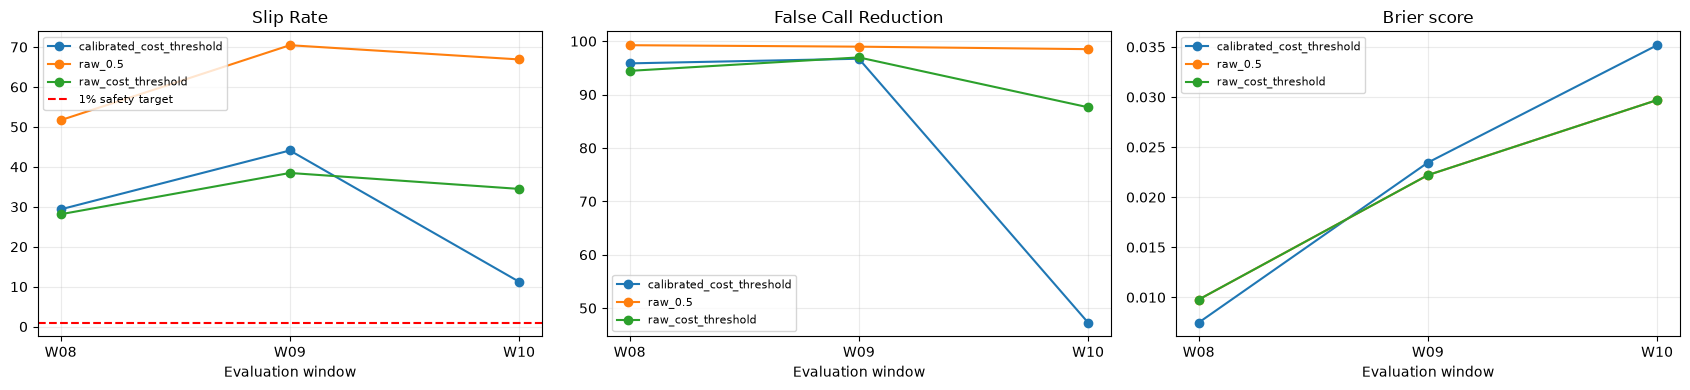

In [8]:
calibration_comparison = window_policy_summary.loc[
    pd.IndexSlice[:, ["raw_cost_threshold", "calibrated_cost_threshold"]],
    ["brier", "log_loss", "mean_probability", "observed_rate"]
].copy()
display(calibration_comparison)

plot_df = window_policy_summary.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for policy, group in plot_df.groupby("policy"):
    axes[0].plot(group["evaluation_window"], group["slip_rate"] * 100, marker="o", label=policy)
    axes[1].plot(group["evaluation_window"], group["volume_reduction"] * 100, marker="o", label=policy)
    axes[2].plot(group["evaluation_window"], group["brier"], marker="o", label=policy)
axes[0].axhline(1.0, color="red", linestyle="--", label="1% safety target")
axes[0].set_title("Slip Rate")
axes[1].set_title("False Call Reduction")
axes[2].set_title("Brier score")
for ax in axes:
    ax.set_xlabel("Evaluation window")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. `kimjaehak_006` 재현과 결론

W09~W10 raw 0.5 결과를 재현한 뒤, 전체 결과로 다음 단계 진행 여부를 판정합니다.

In [9]:
original_test_rows = row_policy_predictions.loc[
    row_policy_predictions["evaluation_window"].isin(["W09", "W10"])
    & (row_policy_predictions["policy"] == "raw_0.5")
]
reproduced_006 = summarize_policy_rows(original_test_rows)
assert np.isclose(reproduced_006["pr_auc"], 0.315411, atol=5e-6)
assert np.isclose(reproduced_006["recall"], 0.316141, atol=5e-6)

raw_cost = aggregate_policy_summary.loc["raw_cost_threshold"]
calibrated_cost = aggregate_policy_summary.loc["calibrated_cost_threshold"]
window_calibrated = window_policy_summary.xs("calibrated_cost_threshold", level="policy")
type_updates = int((calibrator_history["source"] == "type_updated").sum())
fallbacks = int((calibrator_history["source"] == "pooled_fallback").sum())
retained = int((calibrator_history["source"] == "type_retained").sum())
monotonic_fallbacks = int(calibrator_history["monotonic_fallback"].sum())

conclusion = f"""
### 실행 결과

- W09~W10 raw 0.5는 PR-AUC **{reproduced_006['pr_auc']:.6f}**, Recall **{reproduced_006['recall']:.6f}**로 `kimjaehak_006`을 재현했습니다.
- 비용 threshold는 모든 type과 구간에서 **{COST_PROBABILITY_THRESHOLD:.6f}**로 고정했습니다.
- W08~W10 raw score 비용 정책은 Slip Rate **{raw_cost['slip_rate']:.2%}**, False Call Reduction **{raw_cost['volume_reduction']:.2%}**, 총비용 **{int(raw_cost['total_cost_1_to_100']):,}**이었습니다.
- calibrated probability 비용 정책은 Slip Rate **{calibrated_cost['slip_rate']:.2%}**, False Call Reduction **{calibrated_cost['volume_reduction']:.2%}**, 총비용 **{int(calibrated_cost['total_cost_1_to_100']):,}**이었습니다.
- calibrated 정책의 구간별 Slip Rate는 W08 **{window_calibrated.loc['W08', 'slip_rate']:.2%}**, W09 **{window_calibrated.loc['W09', 'slip_rate']:.2%}**, W10 **{window_calibrated.loc['W10', 'slip_rate']:.2%}**입니다.
- type calibration 갱신은 **{type_updates}회**, pooled fallback은 **{fallbacks}회**, 이전 type calibrator 유지는 **{retained}회**였습니다.
- 음수 slope를 0으로 제한한 monotonic fallback은 **{monotonic_fallbacks}회** 적용됐습니다.
- 전체 Brier score는 raw **{raw_cost['brier']:.6f}**, calibrated **{calibrated_cost['brier']:.6f}**입니다.

### 판정

Platt calibration은 각 type 안에서 score 순서를 바꾸지 않지만, score를 비용 threshold와 비교할 수 있는 확률 단위로 바꿉니다. 따라서 Brier/log loss 개선과 비용·안전 지표를 함께 봐야 합니다.

고정 비용 threshold가 미래 세 구간에서 Slip Rate 1%를 안정적으로 만족하지 못하거나 calibration 품질이 시간에 따라 크게 흔들리면, 다음 단계로 W01~W06 모델 자체를 고정하는 가정을 풀고 expanding 또는 rolling 재학습을 별도 실험으로 검토합니다.
"""
display(Markdown(conclusion))


### 실행 결과

- W09~W10 raw 0.5는 PR-AUC **0.315411**, Recall **0.316141**로 `kimjaehak_006`을 재현했습니다.
- 비용 threshold는 모든 type과 구간에서 **0.009901**로 고정했습니다.
- W08~W10 raw score 비용 정책은 Slip Rate **35.13%**, False Call Reduction **93.04%**, 총비용 **98,508**이었습니다.
- calibrated probability 비용 정책은 Slip Rate **25.54%**, False Call Reduction **80.14%**, 총비용 **88,644**이었습니다.
- calibrated 정책의 구간별 Slip Rate는 W08 **29.36%**, W09 **44.10%**, W10 **11.24%**입니다.
- type calibration 갱신은 **9회**, pooled fallback은 **5회**, 이전 type calibrator 유지는 **1회**였습니다.
- 음수 slope를 0으로 제한한 monotonic fallback은 **2회** 적용됐습니다.
- 전체 Brier score는 raw **0.020556**, calibrated **0.022032**입니다.

### 판정

Platt calibration은 각 type 안에서 score 순서를 바꾸지 않지만, score를 비용 threshold와 비교할 수 있는 확률 단위로 바꿉니다. 따라서 Brier/log loss 개선과 비용·안전 지표를 함께 봐야 합니다.

고정 비용 threshold가 미래 세 구간에서 Slip Rate 1%를 안정적으로 만족하지 못하거나 calibration 품질이 시간에 따라 크게 흔들리면, 다음 단계로 W01~W06 모델 자체를 고정하는 가정을 풀고 expanding 또는 rolling 재학습을 별도 실험으로 검토합니다.
